<a href="https://colab.research.google.com/github/faizanahmed-ai/flyrank-ml-internship/blob/main/work/notebooks/w05_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/faizanahmed-ai/flyrank-ml-internship/blob/main/work/notebooks/w05_model.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## Objective

Build an honest, reproducible model that prioritizes pages for **human content review**. The task is not to predict Google's algorithm or guarantee that a refresh will work. It is to rank pages in the observed declining-trend category better than a simple, transparent rule, on clients the model did not see during training.

## 1. Method choice and why

*Which method from the toolkit, and why it fits your lane.*

This is a **binary classification used for ranking**: each page receives a probability, then the highest-probability pages form a review queue. I compare:

- a transparent stale-and-visible baseline, which anyone can inspect;
- logistic regression, a stable and readable learned benchmark; and
- random forest, which can represent nonlinear interactions between visibility, freshness, position, CTR, engagement, and content size.

The selected model is the one with the best held-out Precision@50. This aligns the model-selection rule with the real use case: an editor reviews the top of a finite queue.


In [7]:
# Works in Colab, Jupyter, or from any folder inside a clone of this repository.
from pathlib import Path
import os
import urllib.request

DATA_NAME = "content_refresh_anonymized.csv"
ROOT = Path.cwd().resolve()

# First, look upward for an extracted internship repository.
candidate_roots = [ROOT, *ROOT.parents]
data_path = next((p / "data" / "raw" / DATA_NAME for p in candidate_roots if (p / "data" / "raw" / DATA_NAME).exists()), None)

# If the notebook was opened alone (for example in /tmp), download only the public,
# anonymized starter CSV into a small local workspace. No private data or credentials are used.
if data_path is None:
    ROOT = Path.cwd().resolve() / "flyrank_notebook_workspace"
    data_path = ROOT / "data" / "raw" / DATA_NAME
    data_path.parent.mkdir(parents=True, exist_ok=True)
    if not data_path.exists():
        url = "https://raw.githubusercontent.com/flyrank-bih/flyrank-ml-internship-starter/main/data/raw/content_refresh_anonymized.csv"
        print("Starter dataset was not found locally; downloading the public anonymized CSV once...")
        try:
            urllib.request.urlretrieve(url, data_path)
        except Exception as exc:
            raise FileNotFoundError(
                "The starter CSV was not found locally and could not be downloaded. "
                "Extract the internship ZIP and open this notebook from it, or place "
                "content_refresh_anonymized.csv beside the notebook before running again."
            ) from exc
else:
    ROOT = data_path.parents[2]

os.chdir(ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    from IPython.display import display
except ImportError:  # Allows a plain local Python run as well as Jupyter/Colab.
    def display(value):
        print(value)
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
OUT_DIR = ROOT / "work" / "outputs"
FIG_DIR = ROOT / "work" / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
print("Working folder:", ROOT)
print("Dataset:", data_path)



Starter dataset was not found locally; downloading the public anonymized CSV once...
Working folder: /flyrank_notebook_workspace
Dataset: /flyrank_notebook_workspace/data/raw/content_refresh_anonymized.csv


## 2. Split design

*Grouped by client? Time-aware? Say why this split is honest for your question.*

One row is one pseudonymized content item. The target is the dataset's observed `trend_direction == "down"` category. Because `trend_direction` is derived from `trend_pct`, both are excluded from features. Content and client IDs are also excluded from the model; client ID is used only to construct a grouped split.

The evaluation uses a fixed 80/20 **client holdout** (seed 42): all pages from a held-out client are unseen during training. This checks cross-client generalization and avoids the overly optimistic result that a random page split can create. It is still not a time-forward study, because the starter release is a trailing-window snapshot.


In [8]:
df = pd.read_csv(data_path)

# This is an observed trailing-window category, not a claim about a future intervention.
df["is_declining_label"] = df["trend_direction"].astype(str).str.lower().eq("down").astype(int)

# Log transforms reduce the influence of highly skewed traffic fields.
for raw in ["impressions_90d", "clicks_90d", "sessions_90d"]:
    if raw in df:
        df[f"log_{raw}"] = np.log1p(pd.to_numeric(df[raw], errors="coerce").clip(lower=0))

print(f"Rows: {len(df):,}")
print(f"Clients: {df['client_id'].nunique():,}")
print(f"Observed declining-label rate: {df['is_declining_label'].mean():.3f}")
display(df[["impressions_90d", "days_since_last_update", "avg_position", "ctr", "is_declining_label"]].describe().T)

Rows: 30,000
Clients: 32
Observed declining-label rate: 0.542


,count,mean,std,min,25%,50%,75%,max
impressions_90d,30000.0,5200.366300,16838.019547,1.0,81.0,731.00,3615.25,517715.0
days_since_last_update,30000.0,46.098300,42.078709,1.0,20.0,20.00,104.00,373.0
avg_position,30000.0,16.342380,15.216790,0.0,6.2,10.80,22.30,245.0
ctr,30000.0,0.510733,3.279162,0.0,0.0,0.07,0.29,100.0
is_declining_label,30000.0,0.542067,0.498236,0.0,0.0,1.00,1.00,1.0


In [9]:
# Deliberately exclude label-derived fields and IDs from the feature vector.
excluded = ["trend_direction", "trend_pct", "content_id", "client_id"]
numeric_features = [
    "log_impressions_90d", "log_clicks_90d", "log_sessions_90d",
    "days_with_impressions", "days_with_sessions", "content_age_days",
    "days_since_last_update", "avg_position", "ctr", "engagement_rate",
    "scroll_rate", "word_count", "char_count",
]
categorical_features = ["content_type", "main_intent", "freshness_tier", "position_tier"]
numeric_features = [c for c in numeric_features if c in df.columns]
categorical_features = [c for c in categorical_features if c in df.columns]
feature_columns = numeric_features + categorical_features

X = df[feature_columns].copy()
y = df["is_declining_label"].astype(int)
groups = df["client_id"].astype(str)

# A whole client is held out: no page from a held-out client appears during training.
splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

def precision_at_k(y_true, scores, k=50):
    y_array = np.asarray(y_true)
    order = np.argsort(-np.asarray(scores))
    return float(y_array[order[:min(k, len(order))]].mean())

# Baseline is a transparent review heuristic. It is scored only on the held-out clients.
baseline_scores = (
    ((df["days_since_last_update"] >= 180) & (df["impressions_90d"] >= 500)).astype(float)
    * np.log1p(df["impressions_90d"].clip(lower=0))
)
print(f"Train rows: {len(train_idx):,} | held-out rows: {len(test_idx):,} | held-out clients: {groups.iloc[test_idx].nunique()}")
print(f"Held-out base rate: {y_test.mean():.3f} | baseline Precision@50: {precision_at_k(y_test, baseline_scores.iloc[test_idx]):.3f}")


Train rows: 23,837 | held-out rows: 6,163 | held-out clients: 7
Held-out base rate: 0.511 | baseline Precision@50: 0.620


## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*

Every model below uses the same feature set, held-out clients, and ranking metric. The table reports ROC-AUC, average precision, Precision@20, Precision@50, and the held-out base rate. Precision@50 is the selection metric; a large ROC-AUC alone would not prove that the top of the review queue is useful.


In [10]:
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipe, numeric_features),
    ("categorical", categorical_pipe, categorical_features),
])

estimators = {
    "logistic_regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
    "random_forest": RandomForestClassifier(
        n_estimators=300, max_depth=10, min_samples_leaf=25,
        class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=-1,
    ),
}

fitted_models, model_scores, rows = {}, {}, []
for model_name, estimator in estimators.items():
    pipe = Pipeline([("preprocess", preprocessor), ("model", estimator)])
    pipe.fit(X_train, y_train)
    probability = pipe.predict_proba(X_test)[:, 1]
    fitted_models[model_name] = pipe
    model_scores[model_name] = probability
    rows.append({
        "model": model_name,
        "roc_auc": roc_auc_score(y_test, probability),
        "average_precision": average_precision_score(y_test, probability),
        "precision_at_20": precision_at_k(y_test, probability, 20),
        "precision_at_50": precision_at_k(y_test, probability, 50),
        "held_out_base_rate": y_test.mean(),
    })

results = pd.DataFrame(rows).sort_values("precision_at_50", ascending=False).reset_index(drop=True)
baseline_row = pd.DataFrame([{
    "model": "transparent_stale_visible_baseline",
    "roc_auc": roc_auc_score(y_test, baseline_scores.iloc[test_idx]),
    "average_precision": average_precision_score(y_test, baseline_scores.iloc[test_idx]),
    "precision_at_20": precision_at_k(y_test, baseline_scores.iloc[test_idx], 20),
    "precision_at_50": precision_at_k(y_test, baseline_scores.iloc[test_idx], 50),
    "held_out_base_rate": y_test.mean(),
}])
comparison = pd.concat([baseline_row, results], ignore_index=True)
display(comparison.round(3))
comparison.to_csv(OUT_DIR / "w05_model_comparison.csv", index=False)
best_name = results.iloc[0]["model"]
best_model = fitted_models[best_name]
best_probability = model_scores[best_name]
print("Selected model by held-out Precision@50:", best_name)


,model,roc_auc,average_precision,precision_at_20,precision_at_50,held_out_base_rate
0,transparent_stale_visible_baseline,0.500,0.511,0.45,0.62,0.511
1,logistic_regression,0.622,0.612,0.90,0.74,0.511
2,random_forest,0.623,0.605,0.50,0.58,0.511


Selected model by held-out Precision@50: logistic_regression


## 4. Errors and interpretation

*Where is the model wrong? What does it lean on? A short error analysis beats a big metric table.*

Feature importance describes how the fitted model used this dataset; it does not establish causation. The code inspects false positives and false negatives from held-out clients and writes only safe summary artifacts to `work/outputs/` and `work/figures/`. Before a recommendation is acted on, a person must check intent, seasonality, indexing, product changes, and editorial context.


,feature,importance
0,numeric__log_impressions_90d,1.087898
28,categorical__position_tier_top_3,0.967731
21,categorical__freshness_tier_181+,0.700576
1,numeric__log_clicks_90d,0.578361
13,categorical__content_type_comparison article,0.398530
5,numeric__content_age_days,0.385972
7,numeric__avg_position,0.362498
18,categorical__main_intent_navigational,0.304333
12,numeric__char_count,0.270268
11,numeric__word_count,0.268000


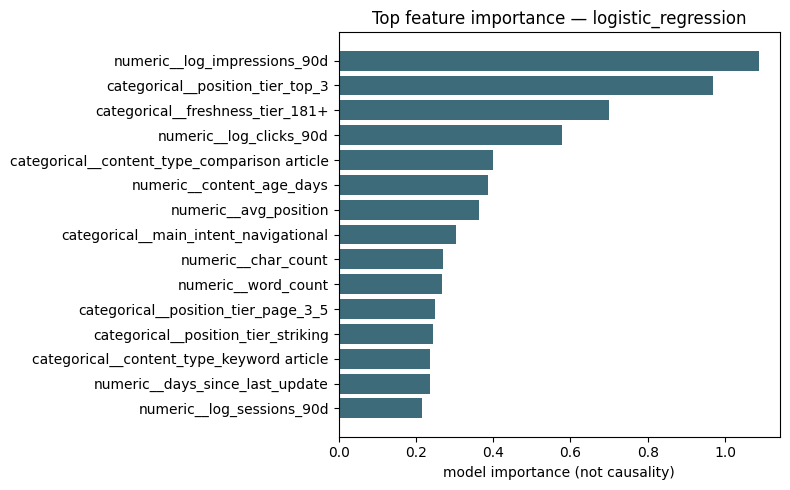

False positives: 1214 | False negatives: 1360


,client_id,impressions_90d,days_since_last_update,avg_position,ctr,trend_direction,observed_declining,decline_probability,predicted_declining
26614,client_f369cb89fc,290,20,5.9,0.00,up,0,0.919802,1
27993,client_f369cb89fc,1266,106,4.6,0.00,up,0,0.910021,1
7665,client_f369cb89fc,2628,20,12.0,0.04,stable,0,0.881639,1
10175,client_f369cb89fc,235,20,31.0,0.85,stable,0,0.876028,1
17500,client_f369cb89fc,581,8,5.4,0.00,up,0,0.875723,1


,client_id,impressions_90d,days_since_last_update,avg_position,ctr,trend_direction,observed_declining,decline_probability,predicted_declining
29158,client_4e07408562,3,20,2.0,0.00,down,1,0.066322,0
27213,client_8527a891e2,4,20,77.5,0.00,down,1,0.089600,0
21819,client_4e07408562,463103,20,2.3,0.41,down,1,0.090254,0
1725,client_8527a891e2,1,20,3.0,0.00,down,1,0.094934,0
8407,client_4e07408562,2,104,45.0,0.00,down,1,0.099623,0


In [12]:
# Interpret the selected model and inspect errors before treating the score as useful.
feature_names = best_model.named_steps["preprocess"].get_feature_names_out()
classifier = best_model.named_steps["model"]
if hasattr(classifier, "feature_importances_"):
    importance = pd.DataFrame({"feature": feature_names, "importance": classifier.feature_importances_})
else:
    importance = pd.DataFrame({"feature": feature_names, "importance": np.abs(classifier.coef_[0])})
importance = importance.sort_values("importance", ascending=False).head(15)
display(importance)

plt.figure(figsize=(8, 5))
plot_data = importance.sort_values("importance")
plt.barh(plot_data["feature"], plot_data["importance"], color="#3d6b7a")
plt.title(f"Top feature importance — {best_name}")
plt.xlabel("model importance (not causality)")
plt.tight_layout()
plt.savefig(FIG_DIR / "w05_feature_importance.png", dpi=160)
plt.show()

errors = df.iloc[test_idx][["client_id", "impressions_90d", "days_since_last_update", "avg_position", "ctr", "trend_direction"]].copy()
errors["observed_declining"] = y_test.to_numpy()
errors["decline_probability"] = best_probability
errors["predicted_declining"] = (best_probability >= 0.50).astype(int)
false_positives = errors[(errors["predicted_declining"] == 1) & (errors["observed_declining"] == 0)].sort_values("decline_probability", ascending=False)
false_negatives = errors[(errors["predicted_declining"] == 0) & (errors["observed_declining"] == 1)].sort_values("decline_probability")
print("False positives:", len(false_positives), "| False negatives:", len(false_negatives))
display(false_positives.head(5))
display(false_negatives.head(5))
errors.to_csv(OUT_DIR / "w05_heldout_error_analysis.csv", index=False)

## Findings and limits

Report the table produced by your own run, not a copied headline. The conclusion this notebook can support is: *on held-out clients in this anonymized release, the selected model ranked the observed declining category at the reported Precision@50 relative to the transparent baseline.* It cannot support: *refreshing a page will increase traffic*, *a feature causes a decline*, or *the model predicts Google's algorithm*.

## Reproducibility checklist

- Fixed seed: `42`
- Grouped client holdout, not an in-sample result
- Target-derived fields (`trend_direction`, `trend_pct`) excluded
- Same held-out data and metrics for baseline and learned models
- Comparison CSV, error-analysis CSV, and feature-importance figure exported
- Results used as a human-review aid only


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.